## 0. 라이브러리 생성, 데이터 불러오기, 데이터 기본 정보 확인

In [1]:
import numpy as np                  # 수치 계산/벡터·행렬 연산(NumPy)
import pandas as pd                 # 데이터프레임 생성·가공·요약(Pandas)

import matplotlib.pyplot as plt     # 기본 시각화 라이브러리(Matplotlib)
plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 한글 폰트 설정
plt.rcParams["axes.unicode_minus"] = False      # 그래프의 마이너스 기호 깨짐 방지

from IPython.display import display # 노트북에서 DataFrame 등을 예쁘게 출력할 때 사용
import seaborn as sns               # 통계 시각화 라이브러리
from scipy.stats import chi2_contingency # 카이제곱 검정


In [2]:
# 데이터 불러오기
data = pd.read_csv("Titanic-Dataset.csv") 
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# 위에서 5행 보기
data.head() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 아래에서 5행 보기
data.tail() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
# 행 개수, 열 개수
data.shape  

(891, 12)

In [6]:
# 변수(열) 이름 목록
data.columns 

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [7]:
# 변수별 자료형
data.dtypes 

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [8]:
# 숫자형 변수의 요약통계량

numeric_data = data.select_dtypes(include='number') # 숫자형 변수만 추출

numeric_data.describe()  

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# 변수별 고유값 개수 → 범주형인지 추측
data.nunique() 

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [10]:
# 변수별 결측치 개수
data.isnull().sum() 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
# 모든 변수가 다 NA인 행
data.isnull().all(axis=1) #

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [12]:
# 모든 변수가 다 NA인 행 개수
data.isna().all(axis=1).sum() 

np.int64(0)

# 🎯 제출 과제

## 과제 1. 생존과 연관된 변수 찾기
- 추가 EDA를 진행해 **`Survived`와 관련이 깊은 변수**를 찾고, 그렇게 판단한 근거를 정리하세요.
- 단순히 그래프만 그리지 말고 **가설검정·통계분석**(예: 교차표 + 카이제곱검정, 그룹별 평균 비교 등)으로 뒷받침해 보세요.
- 발견한 내용을 마크다운 셀에 **인사이트(insight)** 로 3줄 이상 정리하세요.

## 과제 2. Age 결측값 채우기
- `Age`에는 결측치가 많습니다. 이를 **합리적인 방법으로 채워** 보세요.
- 단순 평균/중앙값으로 채우는 것보다, 아래 **이름(Name)의 호칭**을 활용하면 더 정교하게 채울 수 있습니다.
- 왜 그 방법을 골랐는지 근거도 함께 적으세요.

> 아래 셀들은 과제 2의 힌트입니다. 이름에서 호칭(Mr, Miss, Mrs, Master 등)을 뽑아내는 데 참고하세요.

## 과제 1. 생존과 연관된 변수 찾기

In [13]:
# 원본을 복사해서 사용
data1 = data.copy()

# 성별과 생존 여부 교차표
sex_table = pd.crosstab(data1["Sex"], data1["Survived"])
sex_table


Survived,0,1
Sex,,
female,81,233
male,468,109


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


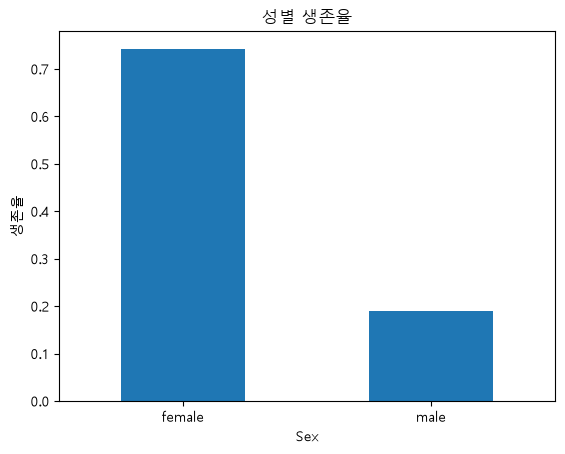

In [14]:
# 성별 생존율 확인
sex_survival_rate = data1.groupby("Sex")["Survived"].mean()
print(sex_survival_rate)

# 막대그래프
sex_survival_rate.plot(kind="bar", rot=0)
plt.title("성별 생존율")
plt.ylabel("생존율")
plt.show()


# 여성(female) : 0.7420
# 남성(male)   : 0.1889 으로 성별간 생존율의 차이가 있는 것으로 의심된다.

## 성별과 생존 여부 카이제곱검정

- p-value가 0.05 보다 작으면 성별과 생존 여부가 관련 있다고 판단

In [15]:
# 카이제곱검정
# H0 : 성별과 생존 여부는 서로 관련이 없다. (남성과 여성의 생존 비율은 동일하다.)
# H1 : 성별과 생존 여부는 서로 관련이 있다. (남성과 여성의 생존 비율은 다르다.)

chi2, p_value, dof, expected = chi2_contingency(sex_table)

print("카이제곱 통계량:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print("성별과 생존 여부는 관련이 있다고 볼 수 있다.")
else:
    print("성별과 생존 여부는 관련이 없다고 볼 수 있다.")


카이제곱 통계량: 260.71702016732104
p-value: 1.1973570627755645e-58
성별과 생존 여부는 관련이 있다고 볼 수 있다.


In [16]:
# 객실 등급과 생존 여부 교차표
class_table = pd.crosstab(data1["Pclass"], data1["Survived"])
class_table


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


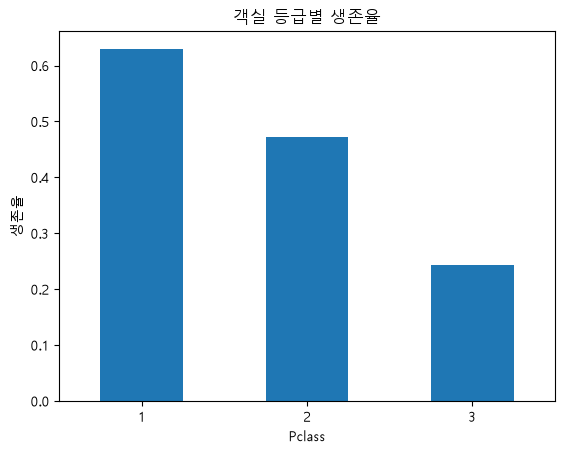

In [17]:
# 객실 등급별 생존율
class_survival_rate = data1.groupby("Pclass")["Survived"].mean()
print(class_survival_rate)

class_survival_rate.plot(kind="bar", rot=0)
plt.title("객실 등급별 생존율")
plt.ylabel("생존율")
plt.show()


In [18]:
# 객실 등급과 생존 여부 카이제곱검정
# H0 : 객실 등급과 생존 여부는 서로 관련이 없다. (1등급, 2등급, 3등급의 생존 비율은 동일하다.)
# H1 : 객실 등급과 생존 여부는 서로 관련이 있다. (세 객실 등급 중 적어도 하나의 생존 비율이 다르다.)

chi2, p_value, dof, expected = chi2_contingency(class_table)

print("카이제곱 통계량:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print("객실 등급과 생존 여부는 관련이 있다고 볼 수 있다.")
else:
    print("객실 등급과 생존 여부는 관련이 없다고 볼 수 있다.")


카이제곱 통계량: 102.88898875696056
p-value: 4.549251711298793e-23
객실 등급과 생존 여부는 관련이 있다고 볼 수 있다.


## 과제 1 인사이트

1. 여성의 생존율은 약 74.2%, 남성의 생존율은 약 18.9%로 성별에 따른 생존율 차이가 크게 나타났다.  
2. 성별과 생존 여부의 카이제곱검정 결과 p-value가 0.05보다 작아, 성별과 생존 여부가 통계적으로 관련되어 있다고 판단하였다.  
3. 객실 등급별 생존율은 1등석 약 63.0%, 2등석 약 47.3%, 3등석 약 24.2%로 객실 등급이 낮아질수록 생존율도 낮아지는 경향이 나타났다.  
4. 객실 등급과 생존 여부의 카이제곱검정 결과도 p-value가 0.05보다 작아, 객실 등급과 생존 여부가 통계적으로 관련되어 있다고 판단하였다.  
5. 따라서 이번 분석에서는 성별과 객실 등급이 생존 여부와 관련이 깊은 변수라고 판단하였다.


## 과제 2. Age 결측값 채우기
- `Age`에는 결측치가 많습니다. 이를 **합리적인 방법으로 채워** 보세요.
- 단순 평균/중앙값으로 채우는 것보다, 아래 **이름(Name)의 호칭**을 활용하면 더 정교하게 채울 수 있습니다.
- 왜 그 방법을 골랐는지 근거도 함께 적으세요.

**호칭별 의미와 전처리 방향**

- **Mr**: 성인 남성에게 주로 사용되는 호칭
- **Miss**: 미혼 여성 또는 여자아이에게 사용되는 호칭
- **Mrs**: 기혼 여성에게 주로 사용되는 호칭
- **Master**: 남자아이에게 주로 사용되는 호칭
- **Dr**: 의사·박사 등의 호칭

호칭은 승객의 성별과 대략적인 연령대를 간접적으로 나타낼 수 있다.  
이번 과제에서는 서로 다른 방법을 같은 원본 데이터에 적용하고, 실제 나이가 존재하는 일부 값을 임시로 가린 뒤 평균절대오차(MAE)를 비교해 최종 방법을 선택한다. 
# 데이터 마이닝 - training, test 데이터 분할 기법 이용 
# 모델 성능 확인 : MAE 기법(mean absolute error) 


In [19]:
# 과제 2는 Age가 수정되지 않은 원본 데이터에서 다시 시작
data1 = data.copy()

# 원래 Age 값을 비교용으로 보존
data1["Age_before"] = data1["Age"]

print("채우기 전 Age 결측치 개수:", data1["Age"].isnull().sum())


채우기 전 Age 결측치 개수: 177


In [20]:
# Age 결측치가 있는 승객 일부 확인
data1.loc[
    data1["Age"].isnull(),
    ["PassengerId", "Name", "Sex", "Pclass", "Age"]
].head(10)


,PassengerId,Name,Sex,Pclass,Age
5,6,"Moran, Mr. James",male,3,NaN
17,18,"Williams, Mr. Charles Eugene",male,2,NaN
19,20,"Masselmani, Mrs. Fatima",female,3,NaN
26,27,"Emir, Mr. Farred Chehab",male,3,NaN
28,29,"O'Dwyer, Miss. Ellen ""Nellie""",female,3,NaN
29,30,"Todoroff, Mr. Lalio",male,3,NaN
31,32,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,1,NaN
32,33,"Glynn, Miss. Mary Agatha",female,3,NaN
36,37,"Mamee, Mr. Hanna",male,3,NaN
42,43,"Kraeff, Mr. Theodor",male,3,NaN


In [21]:
# 이름에서 호칭 추출
data1["Title"] = data1["Name"].str.extract(r',\s*([^.]*)\.')

# 의미가 같은 호칭 통합
data1["Title_Group"] = data1["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

# 표본이 매우 적은 호칭은 Rare로 통합
main_titles = ["Mr", "Miss", "Mrs", "Master", "Dr"]
data1.loc[~data1["Title_Group"].isin(main_titles), "Title_Group"] = "Rare"

data1[["Name", "Title", "Title_Group"]].head()


,Name,Title,Title_Group
0,"Braund, Mr. Owen Harris",Mr,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,Mrs
2,"Heikkinen, Miss. Laina",Miss,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,Mrs
4,"Allen, Mr. William Henry",Mr,Mr


In [22]:
# 정리된 호칭별 인원수 확인
data1["Title_Group"].value_counts()


Title_Group
Mr        517
Miss      185
Mrs       126
Master     40
Rare       16
Dr          7
Name: count, dtype: int64

In [23]:
# 호칭별 나이의 개수·평균·중앙값 확인
title_age_summary = data1.groupby("Title_Group")["Age"].agg(
    Count="count",
    Mean="mean",
    Median="median"
)

title_age_summary


,Count,Mean,Median
Title_Group,,,
Dr,6,42.000000,46.5
Master,36,4.574167,3.5
Miss,149,21.845638,21.0
Mr,398,32.368090,30.0
Mrs,109,35.788991,35.0
Rare,16,46.875000,48.5


In [24]:
# 방법 1) 호칭별 평균으로 Age 결측치 대체
data_title_mean = data1.copy()

data_title_mean["Age"] = data_title_mean["Age"].fillna(
    data_title_mean.groupby("Title_Group")["Age"].transform("mean")
)

# 예외적으로 남은 결측치는 전체 평균으로 대체
data_title_mean["Age"] = data_title_mean["Age"].fillna(
    data_title_mean["Age"].mean()
)

print("방법 1 처리 후 Age 결측치:", data_title_mean["Age"].isnull().sum())


방법 1 처리 후 Age 결측치: 0


In [25]:
# 방법 1로 실제 채워진 행 일부 확인
data_title_mean.loc[
    data_title_mean["Age_before"].isnull(),
    ["Name", "Title_Group", "Age_before", "Age"]
].head(10)


,Name,Title_Group,Age_before,Age
5,"Moran, Mr. James",Mr,NaN,32.368090
17,"Williams, Mr. Charles Eugene",Mr,NaN,32.368090
19,"Masselmani, Mrs. Fatima",Mrs,NaN,35.788991
26,"Emir, Mr. Farred Chehab",Mr,NaN,32.368090
28,"O'Dwyer, Miss. Ellen ""Nellie""",Miss,NaN,21.845638
29,"Todoroff, Mr. Lalio",Mr,NaN,32.368090
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",Mrs,NaN,35.788991
32,"Glynn, Miss. Mary Agatha",Miss,NaN,21.845638
36,"Mamee, Mr. Hanna",Mr,NaN,32.368090
42,"Kraeff, Mr. Theodor",Mr,NaN,32.368090


In [26]:
# 방법 2) 성별과 객실 등급별 중앙값으로 Age 결측치 대체
data_sex_pclass = data1.copy()

data_sex_pclass["Age"] = data_sex_pclass["Age"].fillna(
    data_sex_pclass.groupby(["Sex", "Pclass"])["Age"].transform("median")
)

# 예외적으로 남은 결측치는 전체 중앙값으로 대체
data_sex_pclass["Age"] = data_sex_pclass["Age"].fillna(
    data_sex_pclass["Age"].median()
)

print("방법 2 처리 후 Age 결측치:", data_sex_pclass["Age"].isnull().sum())

data1.groupby(["Sex", "Pclass"])["Age"].median()


방법 2 처리 후 Age 결측치: 0


Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

In [27]:
# 방법 2로 실제 채워진 행 일부 확인
data_sex_pclass.loc[
    data_sex_pclass["Age_before"].isnull(),
    ["Name", "Sex", "Pclass", "Age_before", "Age"]
].head(10)


,Name,Sex,Pclass,Age_before,Age
5,"Moran, Mr. James",male,3,NaN,25.0
17,"Williams, Mr. Charles Eugene",male,2,NaN,30.0
19,"Masselmani, Mrs. Fatima",female,3,NaN,21.5
26,"Emir, Mr. Farred Chehab",male,3,NaN,25.0
28,"O'Dwyer, Miss. Ellen ""Nellie""",female,3,NaN,21.5
29,"Todoroff, Mr. Lalio",male,3,NaN,25.0
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,1,NaN,35.0
32,"Glynn, Miss. Mary Agatha",female,3,NaN,21.5
36,"Mamee, Mr. Hanna",male,3,NaN,25.0
42,"Kraeff, Mr. Theodor",male,3,NaN,25.0


In [28]:
# 방법 3) 호칭과 객실 등급별 중앙값으로 Age 결측치 대체
data_title_pclass = data1.copy()

# 1차: 호칭과 객실 등급별 중앙값
data_title_pclass["Age"] = data_title_pclass["Age"].fillna(
    data_title_pclass.groupby(["Title_Group", "Pclass"])["Age"].transform("median")
)

# 2차: 해당 조합의 관측값이 없으면 호칭별 중앙값
data_title_pclass["Age"] = data_title_pclass["Age"].fillna(
    data_title_pclass.groupby("Title_Group")["Age"].transform("median")
)

# 3차: 그래도 남은 결측치는 전체 중앙값
data_title_pclass["Age"] = data_title_pclass["Age"].fillna(
    data_title_pclass["Age"].median()
)

print("방법 3 처리 후 Age 결측치:", data_title_pclass["Age"].isnull().sum())


방법 3 처리 후 Age 결측치: 0


In [29]:
# 호칭과 객실 등급별 원래 Age 중앙값 확인
data1.pivot_table(
    index="Title_Group",
    columns="Pclass",
    values="Age",
    aggfunc="median"
)


Pclass,1,2,3
Title_Group,,,
Dr,46.5,38.5,NaN
Master,4.0,1.0,4.0
Miss,30.0,24.0,18.0
Mr,40.0,31.0,26.0
Mrs,40.0,32.0,31.0
Rare,48.5,46.5,NaN


In [30]:
# 방법 3으로 실제 채워진 행 일부 확인
data_title_pclass.loc[
    data_title_pclass["Age_before"].isnull(),
    ["Name", "Title_Group", "Pclass", "Age_before", "Age"]
].head(10)


,Name,Title_Group,Pclass,Age_before,Age
5,"Moran, Mr. James",Mr,3,NaN,26.0
17,"Williams, Mr. Charles Eugene",Mr,2,NaN,31.0
19,"Masselmani, Mrs. Fatima",Mrs,3,NaN,31.0
26,"Emir, Mr. Farred Chehab",Mr,3,NaN,26.0
28,"O'Dwyer, Miss. Ellen ""Nellie""",Miss,3,NaN,18.0
29,"Todoroff, Mr. Lalio",Mr,3,NaN,26.0
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",Mrs,1,NaN,40.0
32,"Glynn, Miss. Mary Agatha",Miss,3,NaN,18.0
36,"Mamee, Mr. Hanna",Mr,3,NaN,26.0
42,"Kraeff, Mr. Theodor",Mr,3,NaN,26.0


In [31]:
# 세 방법을 공정하게 비교하기 위한 함수
def impute_age(dataset, method):
    result = dataset.copy()

    if method == "호칭별 평균":
        result["Age"] = result["Age"].fillna(
            result.groupby("Title_Group")["Age"].transform("mean")
        )
        result["Age"] = result["Age"].fillna(result["Age"].mean())

    elif method == "성별·객실등급별 중앙값":
        result["Age"] = result["Age"].fillna(
            result.groupby(["Sex", "Pclass"])["Age"].transform("median")
        )
        result["Age"] = result["Age"].fillna(result["Age"].median())

    elif method == "호칭·객실등급별 중앙값":
        result["Age"] = result["Age"].fillna(
            result.groupby(["Title_Group", "Pclass"])["Age"].transform("median")
        )
        result["Age"] = result["Age"].fillna(
            result.groupby("Title_Group")["Age"].transform("median")
        )
        result["Age"] = result["Age"].fillna(result["Age"].median())

    else:
        raise ValueError("지원하지 않는 결측치 처리 방법입니다.")

    return result


In [ ]:
# 실제 나이가 있는 데이터 중 20%를 임시로 가리고 복원 오차 비교
known_age_index = data1.index[data1["Age"].notnull()]

test_index = data1.loc[known_age_index].sample(
    frac=0.2,
    random_state=42
).index

evaluation_data = data1.copy()
actual_age = evaluation_data.loc[test_index, "Age"].copy()
evaluation_data.loc[test_index, "Age"] = np.nan  # age변수가 존재하는 데이터중에서 0.2 비율로 결측치화

methods = [
    "호칭별 평균",
    "성별·객실등급별 중앙값",
    "호칭·객실등급별 중앙값"
]

mae_result = {}

for method in methods:
    evaluated = impute_age(evaluation_data, method) # 각 결측치 대체 방법을 적용
    predicted_age = evaluated.loc[test_index, "Age"]
    mae_result[method] = (actual_age - predicted_age).abs().mean() # 실제 나이와 채운 나이의 차이 계산

mae_table = (
    pd.Series(mae_result, name="MAE")
    .sort_values()
    .to_frame()
)

mae_table


,MAE
호칭별 평균,8.565183
호칭·객실등급별 중앙값,8.622657
성별·객실등급별 중앙값,10.241259


In [33]:
# MAE가 가장 작은 방법을 최종 방법으로 자동 선택
best_method = mae_table.index[0]
data1 = impute_age(data1, best_method)

print("최종 선택 방법:", best_method)
print("최종 Age 결측치 개수:", data1["Age"].isnull().sum())

# 원래 결측치였던 행의 최종 대체 결과 확인
data1.loc[
    data1["Age_before"].isnull(),
    ["Name", "Title_Group", "Pclass", "Age_before", "Age"]
].head(10)


최종 선택 방법: 호칭별 평균
최종 Age 결측치 개수: 0


,Name,Title_Group,Pclass,Age_before,Age
5,"Moran, Mr. James",Mr,3,NaN,32.368090
17,"Williams, Mr. Charles Eugene",Mr,2,NaN,32.368090
19,"Masselmani, Mrs. Fatima",Mrs,3,NaN,35.788991
26,"Emir, Mr. Farred Chehab",Mr,3,NaN,32.368090
28,"O'Dwyer, Miss. Ellen ""Nellie""",Miss,3,NaN,21.845638
29,"Todoroff, Mr. Lalio",Mr,3,NaN,32.368090
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",Mrs,1,NaN,35.788991
32,"Glynn, Miss. Mary Agatha",Miss,3,NaN,21.845638
36,"Mamee, Mr. Hanna",Mr,3,NaN,32.368090
42,"Kraeff, Mr. Theodor",Mr,3,NaN,32.368090


## 과제 2 인사이트

1. 교육용 자료에서 호칭별로 나이대가 다르다는 것을 알았다. 실제로 이름에서 추출한 호칭별 나이를 확인한 결과, `Master`는 주로 어린 승객으로 구성되고 `Mr`, `Mrs`, `Dr` 등은 상대적으로 높은 연령대를 보였다. 따라서 호칭은 승객의 연령대를 간접적으로 구분하는 데 도움이 된다고 판단하였다.  
2. 그 외 방법으로 호칭·객실등급별 중앙값, 성별·객실등급별 중앙값 방법을 고려하였다. 이때는 한 그룹에 들어있는 나이의 편차가 클 수도 있기에 평균이 아닌 중앙값을 사용하였다.
3. 호칭별 평균, 호칭·객실 등급별 중앙값, 성별·객실 등급별 중앙값의 세 가지 방법을 동일한 원본 결측 데이터에 각각 적용하였다.  
3. 결측치에는 실제 정답이 없으므로, 나이가 존재하는 값 중 20%를 임시로 가린 뒤 각 방법으로 복원하고 실제 나이와의 평균절대오차(MAE)를 비교하였다. MAE가 작을수록 실제 나이에 더 가깝게 복원한 방법이라고 볼 수 있다. (데이터 마이닝 과목의 MAE 기법 사용)
4. 비교 결과 MAE가 가장 작은 방법을 최종 방법 즉, 호칭별 평균방법으로 선택해 원래 `Age` 결측치에 적용하였다. 이 과정에서 `Survived` 변수는 사용하지 않아 데이터 누수가 발생하지 않도록 하였다.
